# 04 - Steering, neuron baseline, and UMAP

Owner: Areeb

Activation patching, SAE feature steering, neuron-vs-feature
monosemanticity baseline (heuristic + LLM-scored), and a UMAP of
the SAE decoder directions.

Requires `ANTHROPIC_API_KEY` set in a `.env` file at the repo root
(loaded automatically below).


## Setup

In [1]:
import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

from dotenv import load_dotenv
load_dotenv(REPO / ".env", override=True)

import torch
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
from mid.config import load_sae_config

MODEL_CFG_YAML = REPO / "configs" / "model_decoder_small.yaml"
MODEL_CHECKPOINT = REPO / "checkpoints" / "decoder_small_best_model.pt"
SAE_CFG_YAML = REPO / "configs" / "sae_decoder_small.yaml"
TOKENIZER_PATH = REPO / "tokenizer_output" / "tokenizer.json"

sae_cfg = load_sae_config(str(SAE_CFG_YAML))
SAE_DIR = REPO / f"data/sae_out/decoder_small/L{sae_cfg.layer}_{sae_cfg.hook_type}"

TARGET_LAYER = sae_cfg.layer
SAE_HOOK_NAME = sae_cfg.hook_name()
MLP_HOOK_NAME = f"blocks.{TARGET_LAYER}.mlp.hook_post"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("SAE dir:", SAE_DIR.relative_to(REPO))


Device: cpu
SAE dir: data/sae_out/decoder_small/L3_stream


## Load model and SAE

In [3]:
from mid.config import load_configs
from mid.model.hooked_model import load_checkpoint

model_cfg, _ = load_configs(str(MODEL_CFG_YAML))
model = load_checkpoint(str(MODEL_CHECKPOINT), model_cfg)
model.eval()
print(f"model: {sum(p.numel() for p in model.parameters()):,} params, "
      f"d_model={model_cfg.d_model}, n_layers={model_cfg.n_layers}")


Moving model to device:  cpu
Model parameters: 1,597,112
Moving model to device:  cpu
model: 1,597,112 params, d_model=128, n_layers=4


In [4]:
from tokenizers import Tokenizer as HFTokenizer
from transformers import PreTrainedTokenizerFast

hf_tok = HFTokenizer.from_file(str(TOKENIZER_PATH))
pt_tok = PreTrainedTokenizerFast(
    tokenizer_object=hf_tok,
    bos_token="<|bos|>", eos_token="<|eos|>",
    unk_token="<|unk|>", pad_token="<|pad|>",
)
# set_tokenizer() tries to fetch a BOS variant from the HF Hub, which fails
# for our local BPE tokenizer. Wire it on by hand and disable BOS prepending.
model.tokenizer = pt_tok
model.cfg.tokenizer_prepends_bos = False
model.cfg.default_prepend_bos = False
print(model.to_tokens("HAMLET:").shape)


torch.Size([1, 2])


In [5]:
from mid.sae.load import load_sae

# SAE checkpoint expected at data/sae_out/decoder_small/L{layer}_{hook_type}/;
# regenerate via notebooks/02b_train_sae.ipynb if absent.
sae = load_sae(str(SAE_DIR), device=DEVICE)
sae.eval()
print(f"SAE: d_in={sae.cfg.d_in}, d_sae={sae.cfg.d_sae}, hook={sae.cfg.metadata.hook_name}")


SAE: d_in=128, d_sae=1024, hook=blocks.3.hook_resid_post


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


## Activation patching

In [6]:
from mid.analysis.patching import patch_activation, compare_outputs

clean_prompt     = "HAMLET:\nTo be, or not to be, that is the"
corrupted_prompt = "FALSTAFF:\nA plague upon thy house, thou villainous"

clean_len = model.to_tokens(clean_prompt).shape[1]
corr_len  = model.to_tokens(corrupted_prompt).shape[1]
pos = min(clean_len, corr_len) - 1
print(f"clean_len={clean_len}, corr_len={corr_len}, patching at pos={pos}")

for layer in range(model_cfg.n_layers):
    hook = f"blocks.{layer}.hook_resid_post"
    delta = patch_activation(model, clean_prompt, corrupted_prompt, hook, pos)
    print(f"layer {layer}: patched_loss - clean_loss = {delta:+.4f}")


clean_len=14, corr_len=12, patching at pos=11
layer 0: patched_loss - clean_loss = +0.2791
layer 1: patched_loss - clean_loss = +0.1699
layer 2: patched_loss - clean_loss = +0.2455
layer 3: patched_loss - clean_loss = +0.2275


In [7]:
from functools import partial

_, corrupted_cache = model.run_with_cache(model.to_tokens(corrupted_prompt))
layer_to_show = 2
hook_to_show = f"blocks.{layer_to_show}.hook_resid_post"

def patch_hook(act, hook, src):
    act[:, pos, :] = src[:, pos, :]
    return act

top = compare_outputs(
    model, clean_prompt, hook_to_show,
    partial(patch_hook, src=corrupted_cache[hook_to_show]),
    top_k=10,
)
print("CLEAN top-10:", top["clean"])
print("PATCHED top-10:", top["patched"])


CLEAN top-10: [(' King', 0.040103036910295486), (' very', 0.019684934988617897), (' world', 0.018494542688131332), (' Duke', 0.016790812835097313), (' man', 0.01244278158992529), (' p', 0.011449355632066727), (' name', 0.011192037723958492), (' c', 0.010237695649266243), (' court', 0.010002752766013145), (' g', 0.009635119698941708)]
PATCHED top-10: [(' King', 0.03958643972873688), (' very', 0.02070879377424717), (' Duke', 0.017334265634417534), (' world', 0.01689571514725685), (' p', 0.011712833307683468), (' man', 0.011589348316192627), (' name', 0.010388377122581005), (' g', 0.010073336772620678), (' c', 0.010029108263552189), (' matter', 0.009954621084034443)]


### Patching effect in SAE feature space

Which SAE features mediate the difference between the clean and corrupted prompts at the patched position?


In [ ]:
# Encode clean / corrupted residuals through the SAE; rank features by |Δ|.
with torch.no_grad():
    _, clean_full = model.run_with_cache(
        model.to_tokens(clean_prompt), names_filter=SAE_HOOK_NAME
    )
    _, corr_full = model.run_with_cache(
        model.to_tokens(corrupted_prompt), names_filter=SAE_HOOK_NAME
    )

clean_resid = clean_full[SAE_HOOK_NAME][0, pos].unsqueeze(0)
corr_resid = corr_full[SAE_HOOK_NAME][0, pos].unsqueeze(0)

with torch.no_grad():
    clean_feat = sae.encode(clean_resid)[0]
    corr_feat = sae.encode(corr_resid)[0]

delta = (clean_feat - corr_feat).abs()
top = delta.topk(5)
print("Top-5 features with biggest |Δ| at the patched position:")
for v, idx in zip(top.values.tolist(), top.indices.tolist()):
    print(
        f"  feature {idx:>4d}  |Δ|={v:.3f}  "
        f"(clean={clean_feat[idx]:.3f}, corr={corr_feat[idx]:.3f})"
    )


## Feature steering

Demonstrate the SAE-feature steering interface on an arbitrary feature (feature_idx=42). The 'real' steering demo, using the most monosemantic feature, comes later.


In [9]:
from mid.analysis.patching import steer_with_feature

FEATURE_IDX = 42
PROMPT = "HAMLET:\nTo be"

for coeff in [0.0, 2.0, 5.0, -2.0]:
    out = steer_with_feature(
        model, sae, FEATURE_IDX, coefficient=coeff,
        prompt=PROMPT, max_new_tokens=30,
    )
    print(f"coeff={coeff:+.1f}: {out}\n")


coeff=+0.0: HAMLET:
To be a man, and a man, a man, a man,
That he is a man, a man, a man, a man,


coeff=+2.0: HAMLET:
To be a man, and that he is a king.

KING HENRY
I am a gentleman of a king, and I know
That he is

coeff=+5.0: HAMLET:
To be a man, and that he is a man.

KING,
I am a man that, and that he is a man.



coeff=-2.0: HAMLET:
To be the King's coming, and let me see the
boyage of the King's name.

KING HENRY
I am not sore



## Monosemanticity baseline

For every neuron and SAE feature: collect top-k activating contexts, score how monosemantic the set looks. Two scoring functions:

- **Heuristic**: `1 - unique_token_ratio` over the snippets. Cheap, blind to varied surface forms.
- **LLM**: send the snippets to Claude Haiku, ask for a 0-1 monosemanticity rating.

We expect SAE features to look more monosemantic than raw MLP neurons. How much more, and where the gap shows up, is what the comparison below answers.


### Setup


In [10]:
from mid.analysis.neuron_baseline import (
    top_activating_neurons, score_monosemanticity, summarize_neuron,
)
import numpy as np

val_ids = np.load(REPO / "tokenizer_output" / "val.npy")
seq_len = 128
n_seqs = 64
slab = val_ids[: n_seqs * seq_len].reshape(n_seqs, seq_len)
dataset_tokens = torch.from_numpy(slab).long().to(DEVICE)
print("dataset_tokens:", dataset_tokens.shape)


dataset_tokens: torch.Size([64, 128])


### Neuron baseline (heuristic)


In [11]:
neuron_top = top_activating_neurons(
    model, dataset_tokens, MLP_HOOK_NAME, k=10, context_window=6,
)
print(f"scored {len(neuron_top)} neurons")

neuron_scores = score_monosemanticity(neuron_top)
example = summarize_neuron(0, neuron_top)
print("neuron 0 top tokens:", example["top_tokens"][:5])
print("neuron 0 sample context:", example["contexts"][0][0][:120])


scored 512 neurons
neuron 0 top tokens: [('the', 2), ('and', 2), ('any', 1), ('power', 1), ('To', 1)]
neuron 0 sample context:  any power
To expel sickness, but pro


### LLM-scored neurons


In [12]:
import os
if os.environ.get("ANTHROPIC_API_KEY"):
    llm_scores = score_monosemanticity(neuron_top, llm_client="anthropic")
    top_n = sorted(llm_scores.items(), key=lambda kv: -kv[1])[:10]
    for i, s in top_n:
        print(f"neuron {i}: llm={s:.2f}  heuristic={neuron_scores[i]:.2f}")
    print(f"... ({len(llm_scores)} neurons scored total)")
else:
    print("ANTHROPIC_API_KEY not set; skipping LLM scoring demo")


  [LLM scoring] 25/512
  [LLM scoring] 50/512
  [LLM scoring] 75/512
  [LLM scoring] 100/512
  [LLM scoring] 125/512
  [LLM scoring] 150/512
  [LLM scoring] 175/512
  [LLM scoring] 200/512
  [LLM scoring] 225/512
  [LLM scoring] 250/512
  [LLM scoring] 275/512
  [LLM scoring] 300/512
  [LLM scoring] 325/512
  [LLM scoring] 350/512
  [LLM scoring] 375/512
  [LLM scoring] 400/512
  [LLM scoring] 425/512
  [LLM scoring] 450/512
  [LLM scoring] 475/512
  [LLM scoring] 500/512
  [LLM scoring] 512/512
neuron 169: llm=0.92  heuristic=0.30
neuron 177: llm=0.92  heuristic=0.38
neuron 266: llm=0.92  heuristic=0.23
neuron 271: llm=0.92  heuristic=0.22
neuron 338: llm=0.92  heuristic=0.22
neuron 488: llm=0.92  heuristic=0.29
neuron 494: llm=0.92  heuristic=0.34
neuron 434: llm=0.88  heuristic=0.22
neuron 25: llm=0.85  heuristic=0.17
neuron 39: llm=0.85  heuristic=0.13
... (512 neurons scored total)


### SAE feature baseline (heuristic)


In [13]:
with torch.no_grad():
    _, resid_cache = model.run_with_cache(dataset_tokens, names_filter=SAE_HOOK_NAME)
    resid = resid_cache[SAE_HOOK_NAME]
    feat = sae.encode(resid)

def _top_contexts_from_acts(acts, tokens, k=10, ctx=6):
    B, S, F_ = acts.shape
    flat = acts.reshape(-1, F_)
    top_vals, top_pos = flat.topk(k, dim=0)
    out = {}
    for fi in range(F_):
        rows = []
        for r in range(k):
            idx = top_pos[r, fi].item()
            b, s = divmod(idx, S)
            a, z = max(0, s - ctx), min(S, s + ctx + 1)
            snippet = model.to_string(tokens[b, a:z])
            rows.append((snippet, top_vals[r, fi].item()))
        out[fi] = rows
    return out

feat_top = _top_contexts_from_acts(feat, dataset_tokens, k=10, ctx=6)
feature_scores = score_monosemanticity(feat_top)
print(f"scored {len(feature_scores)} SAE features")


scored 1024 SAE features


### LLM-scored features


In [14]:
feature_llm_scores = score_monosemanticity(feat_top, llm_client="anthropic")
top_n = sorted(feature_llm_scores.items(), key=lambda kv: -kv[1])[:10]
for i, s in top_n:
    print(f"feature {i}: llm={s:.2f}  heuristic={feature_scores[i]:.2f}")
print(f"... ({len(feature_llm_scores)} features scored total)")


  [LLM scoring] 51/1024
  [LLM scoring] 102/1024
  [LLM scoring] 153/1024
  [LLM scoring] 204/1024
  [LLM scoring] 255/1024
  [LLM scoring] 306/1024
  [LLM scoring] 357/1024
  [LLM scoring] 408/1024
  [LLM scoring] 459/1024
  [LLM scoring] 510/1024
  [LLM scoring] 561/1024
  [LLM scoring] 612/1024
  [LLM scoring] 663/1024
  [LLM scoring] 714/1024
  [LLM scoring] 765/1024
  [LLM scoring] 816/1024
  [LLM scoring] 867/1024
  [LLM scoring] 918/1024
  [LLM scoring] 969/1024
  [LLM scoring] 1020/1024
  [LLM scoring] 1024/1024
feature 778: llm=0.95  heuristic=0.33
feature 285: llm=0.92  heuristic=0.25
feature 321: llm=0.92  heuristic=0.14
feature 369: llm=0.92  heuristic=0.18
feature 382: llm=0.92  heuristic=0.31
feature 388: llm=0.92  heuristic=0.24
feature 521: llm=0.92  heuristic=0.26
feature 783: llm=0.92  heuristic=0.27
feature 881: llm=0.92  heuristic=0.25
feature 914: llm=0.92  heuristic=0.25
... (1024 features scored total)


### Comparison stats


                     n_neurons: 512
                    n_features: 1024
                   neuron_mean: 0.1467145543372174
                  feature_mean: 0.1621116491029404
                 neuron_median: 0.14102564102564108
                feature_median: 0.1578947368421053
     neuron_interpretable_frac: 0.0
    feature_interpretable_frac: 0.0029296875


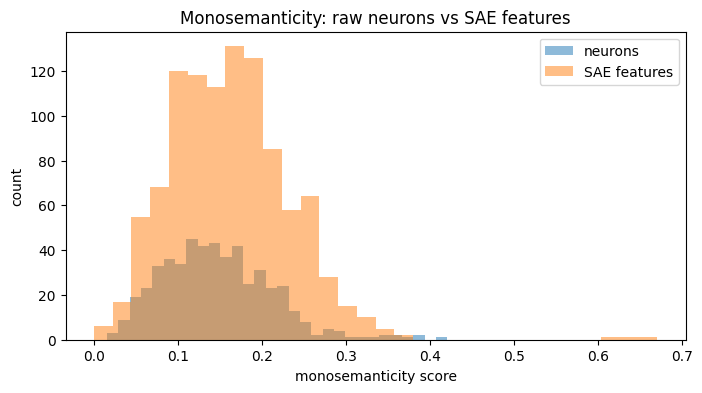

In [15]:
from mid.analysis.neuron_baseline import compare_to_sae

summary = compare_to_sae(neuron_scores, feature_scores, threshold=0.5)
for k, v in summary.items():
    if k.endswith("_sorted"):
        continue
    print(f"{k:>30s}: {v}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(summary["neuron_scores_sorted"], bins=30, alpha=0.5, label="neurons")
ax.hist(summary["feature_scores_sorted"], bins=30, alpha=0.5, label="SAE features")
ax.set_xlabel("monosemanticity score")
ax.set_ylabel("count")
ax.set_title("Monosemanticity: raw neurons vs SAE features")
ax.legend()
plt.show()


In [16]:
llm_summary = compare_to_sae(llm_scores, feature_llm_scores, threshold=0.5)
print("LLM-scored:")
for k, v in llm_summary.items():
    if "sorted" in k:
        continue
    print(f"  {k:>32}: {v}")


LLM-scored:
                         n_neurons: 512
                        n_features: 1024
                       neuron_mean: 0.30826171874999997
                      feature_mean: 0.312158203125
                     neuron_median: 0.25
                    feature_median: 0.25
         neuron_interpretable_frac: 0.19140625
        feature_interpretable_frac: 0.1953125


### Top SAE features (spot-check)

The three highest-LLM-scoring features and their top activating snippets.


In [17]:
top_feats = sorted(feature_llm_scores.items(), key=lambda kv: -kv[1])[:3]
for feat_idx, llm in top_feats:
    h = feature_scores[feat_idx]
    print(f"\n=== feature {feat_idx}  (LLM={llm:.2f}, heuristic={h:.2f}) ===")
    for snippet, act in feat_top[feat_idx][:5]:
        print(f"  [act={act:.2f}]  {snippet!r}")



=== feature 778  (LLM=0.95, heuristic=0.33) ===
  [act=2.64]  '\n\nALCIBIADES  In vain? His'
  [act=2.54]  '\n\nALCIBIADES  Call me to'
  [act=2.51]  '\n\nALCIBIADES\nI cannot think but'
  [act=2.48]  '\n\nALCIBIADES\nMy lords, then'
  [act=2.38]  '\n\nALCIBIADES\nI am an hum'

=== feature 285  (LLM=0.92, heuristic=0.25) ===
  [act=2.28]  "' MAN  Alas, my lord--\n\nTIMON "
  [act=2.10]  ' Five thousand crowns, my lord.\n\nTIMON\n'
  [act=2.09]  ' May it please your Honor, my lord hath\nsent--'
  [act=2.08]  'SIUS  And mine, my lord.\n\nVAR'
  [act=2.00]  'FLAVIUS  Here, my lord.\n\nTIMON\n'

=== feature 321  (LLM=0.92, heuristic=0.14) ===
  [act=2.60]  ' sir.\n\nFLAMINIUS,   Servilius'
  [act=2.41]  'ius?\n\nFLAMINIUS  Faith, nothing but'
  [act=2.29]  ' much.\n\nFLAMINIUS  I need not tell him'
  [act=2.23]  'aster.\n\nFLAMINIUS\nMay these add to the'
  [act=2.09]  ".\n\nPHILOTUS\nI wonder on 't"


### Heuristic-vs-LLM disagreements

Features with low heuristic but high LLM score: cases where the heuristic missed a concept that varied across surface tokens.


In [18]:
disagreements = sorted(
    [
        (i, feature_scores[i], feature_llm_scores[i])
        for i in feature_llm_scores
        if feature_llm_scores[i] >= 0.85 and feature_scores[i] < 0.25
    ],
    key=lambda t: t[2] - t[1],
    reverse=True,
)
print(f"{len(disagreements)} features with heuristic<0.25 and LLM>=0.85.\n")
for feat_idx, h, llm in disagreements[:3]:
    print(f"=== feature {feat_idx}  (LLM={llm:.2f}, heuristic={h:.2f}, gap={llm - h:+.2f}) ===")
    for snippet, act in feat_top[feat_idx][:5]:
        print(f"  [act={act:.2f}]  {snippet!r}")
    print()


21 features with heuristic<0.25 and LLM>=0.85.

=== feature 321  (LLM=0.92, heuristic=0.14, gap=+0.78) ===
  [act=2.60]  ' sir.\n\nFLAMINIUS,   Servilius'
  [act=2.41]  'ius?\n\nFLAMINIUS  Faith, nothing but'
  [act=2.29]  ' much.\n\nFLAMINIUS  I need not tell him'
  [act=2.23]  'aster.\n\nFLAMINIUS\nMay these add to the'
  [act=2.09]  ".\n\nPHILOTUS\nI wonder on 't"

=== feature 65  (LLM=0.85, heuristic=0.07, gap=+0.78) ===
  [act=3.25]  ' me into silence.\n\nTIMON  You gods, re'
  [act=3.03]  ' to beggars.\n\nTHIRD STRANGER\n'
  [act=3.00]  ' crime with this.\n\nSECOND SENATOR  You breat'
  [act=2.98]  'long his hour.\n\nLUCIUS  Who, the Lord'
  [act=2.95]  ' wrongs as gods.\n\nFIRST FRIEND '

=== feature 1008  (LLM=0.85, heuristic=0.07, gap=+0.78) ===
  [act=5.12]  '.\n\nFIRST SENATOR,\nMy lord, you have'
  [act=4.37]  '.\n\nFLAMINIUS,   Servilius,'
  [act=4.10]  '.\n\nSERVILIUS,   See, by good'
  [act=3.67]  '\nTIMON,   Nor more willingly lea'
  [act=2.91]  '\n\nLUCULLUS,   One of 

### Smart steering — top-LLM feature

Steering with the highest-LLM-scoring feature, at gentler coefficients than the arbitrary demo above.

Caveat observed in this run: the top-LLM feature fires on rare contexts (a single character from one play), so the steering direction is sparsely supported. None of the coefficients tested produce ALCIBIADES-content drift — the model collapses into "King" / "I am" loops instead. Steering with the *arbitrary* feature 42 is actually cleaner because that feature has broader support in the corpus. This is a known small-corpus / dead-feature failure mode.


In [23]:
best_feat = max(feature_llm_scores.items(), key=lambda kv: kv[1])[0]
print(f"Steering with feature {best_feat} (LLM={feature_llm_scores[best_feat]:.2f})")
print("Top contexts for this feature:")
for snippet, _ in feat_top[best_feat][:3]:
    print(f"  {snippet!r}")
print()

for coeff in [0.0, 1.0, 1.5, 2.0, -1.0]:
    out = steer_with_feature(
        model, sae, best_feat, coefficient=coeff,
        prompt=PROMPT, max_new_tokens=30,
    )
    print(f"coeff={coeff:+.1f}: {out}\n")


Steering with feature 778 (LLM=0.95)
Top contexts for this feature:
  '\n\nALCIBIADES  In vain? His'
  '\n\nALCIBIADES  Call me to'
  '\n\nALCIBIADES\nI cannot think but'

coeff=+0.0: HAMLET:
To be a man, and a man, a man, a man,
That he is a man, a man, a man, a man,


coeff=+1.0: HAMLET:
To be the King, and the King, and the King
Clower,
And, as I am, I am, and I am,


coeff=+1.5: HAMLET:
To be the King, and the King, and,
And, as I am, I am, and I am,
And, as I am,

coeff=+2.0: HAMLET:
To be the King, and, and, and, to the King
Clay,
And, as I am, I am, and I am

coeff=-1.0: HAMLET:
To be a man's name, and I'll be a king.

KING HENRY
O, let me go with me, and let me go.



### Heuristic-vs-LLM scatter


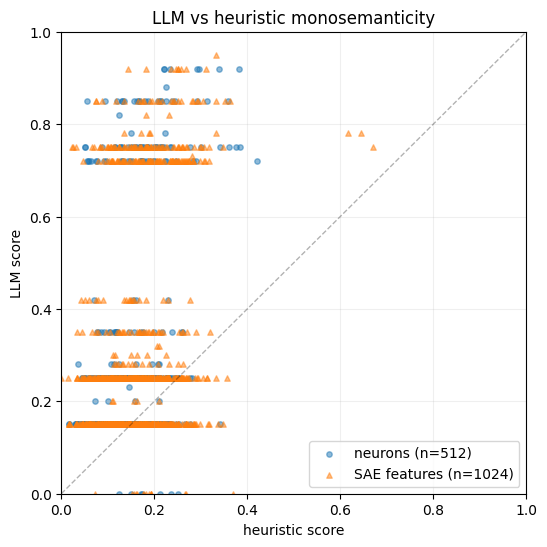

In [24]:
fig, ax = plt.subplots(figsize=(6, 6))
n_x = [neuron_scores[i] for i in llm_scores]
n_y = [llm_scores[i] for i in llm_scores]
f_x = [feature_scores[i] for i in feature_llm_scores]
f_y = [feature_llm_scores[i] for i in feature_llm_scores]
ax.scatter(n_x, n_y, label=f"neurons (n={len(llm_scores)})", alpha=0.5, s=15)
ax.scatter(f_x, f_y, label=f"SAE features (n={len(feature_llm_scores)})", alpha=0.5, s=15, marker="^")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=1)
ax.set_xlabel("heuristic score")
ax.set_ylabel("LLM score")
ax.set_title("LLM vs heuristic monosemanticity")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(); ax.grid(alpha=0.2)
plt.show()


## UMAP of SAE decoder directions

2D projection of the SAE's decoder rows. Each point is one feature direction in residual-stream space. Color by LLM monosemanticity score; the red ring marks the steering target.


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


embeddings: (1024, 2)


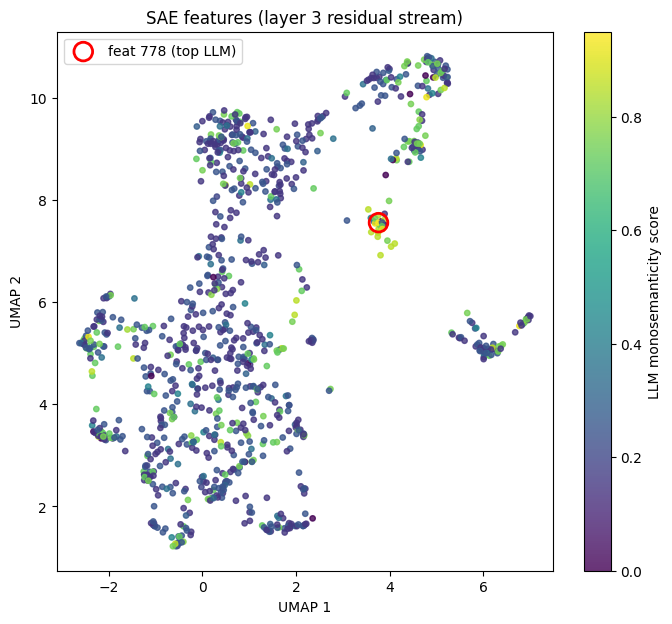

In [25]:
from mid.analysis.umap_features import project_features

emb, fidx = project_features(
    sae, n_components=2, n_neighbors=15, min_dist=0.1, metric="cosine"
)
print("embeddings:", emb.shape)

colors = [feature_llm_scores.get(int(i), 0.0) for i in range(emb.shape[0])]

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(emb[:, 0], emb[:, 1], c=colors, cmap="viridis", s=15, alpha=0.8)
ax.scatter(
    emb[best_feat, 0], emb[best_feat, 1],
    s=180, facecolors="none", edgecolors="red", linewidths=2,
    label=f"feat {best_feat} (top LLM)",
)
plt.colorbar(sc, ax=ax, label="LLM monosemanticity score")
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.set_title(f"SAE features (layer {TARGET_LAYER} residual stream)")
ax.legend()
plt.show()


## Save scores


In [26]:
import json

scores_out = {
    "neuron_heuristic": neuron_scores,
    "feature_heuristic": feature_scores,
    "neuron_llm": llm_scores,
    "feature_llm": feature_llm_scores,
}

out_path = REPO / "data" / "monosemanticity_scores.json"
out_path.parent.mkdir(exist_ok=True)
out_path.write_text(json.dumps({
    k: {str(i): float(v) for i, v in d.items()} for k, d in scores_out.items()
}, indent=2))
print(f"wrote {out_path.relative_to(REPO)}")


wrote data/monosemanticity_scores.json


## Summary


In [27]:
top_feat_idx, top_feat_llm = max(feature_llm_scores.items(), key=lambda kv: kv[1])
top_neur_idx, top_neur_llm = max(llm_scores.items(), key=lambda kv: kv[1])
n_disagree_feat = sum(
    1 for i in feature_llm_scores
    if feature_llm_scores[i] >= 0.85 and feature_scores[i] < 0.25
)
n_disagree_neur = sum(
    1 for i in llm_scores
    if llm_scores[i] >= 0.85 and neuron_scores[i] < 0.25
)
mean_feat = sum(feature_llm_scores.values()) / len(feature_llm_scores)
mean_neur = sum(llm_scores.values()) / len(llm_scores)

print(f"top feature: {top_feat_idx} (LLM {top_feat_llm:.2f})")
print(f"top neuron:  {top_neur_idx} (LLM {top_neur_llm:.2f})")
print()
print(f"mean LLM: features {mean_feat:.3f}, neurons {mean_neur:.3f}")
print()
print(f"high-confidence disagreements (heuristic<0.25, LLM>=0.85):")
print(f"  features: {n_disagree_feat} / {len(feature_llm_scores)}")
print(f"  neurons:  {n_disagree_neur} / {len(llm_scores)}")


top feature: 778 (LLM 0.95)
top neuron:  169 (LLM 0.92)

mean LLM: features 0.312, neurons 0.308

high-confidence disagreements (heuristic<0.25, LLM>=0.85):
  features: 21 / 1024
  neurons:  22 / 512
